In [1]:
import os
import sys
sys.path.append("../") # go to parent dir
%load_ext autoreload
%autoreload 2

In [2]:
from functions.loading_functions import *
train_df = get_dataset("train")
train_df

,Image_ID,class,confidence,ymin,xmin,ymax,xmax,class_id,ImagePath
0,ID_nBgcAR.jpg,healthy,1.0,75.0,15.0,162.0,195.0,2,dataset/images/train/ID_nBgcAR.jpg
1,ID_nBgcAR.jpg,healthy,1.0,58.0,1.0,133.0,171.0,2,dataset/images/train/ID_nBgcAR.jpg
2,ID_nBgcAR.jpg,healthy,1.0,42.0,29.0,377.0,349.0,2,dataset/images/train/ID_nBgcAR.jpg
3,ID_Kw2v8A.jpg,healthy,1.0,112.0,124.0,404.0,341.0,2,dataset/images/train/ID_Kw2v8A.jpg
4,ID_Kw2v8A.jpg,healthy,1.0,148.0,259.0,413.0,412.0,2,dataset/images/train/ID_Kw2v8A.jpg
...,...,...,...,...,...,...,...,...,...
9787,ID_WULBQy.jpeg,anthracnose,1.0,136.0,1440.0,1593.0,4000.0,0,dataset/images/train/ID_WULBQy.jpeg
9788,ID_WULBQy.jpeg,anthracnose,1.0,89.0,0.0,1174.0,1139.0,0,dataset/images/train/ID_WULBQy.jpeg
9789,ID_SVzl5X.jpeg,anthracnose,1.0,18.0,360.0,1800.0,2330.0,0,dataset/images/train/ID_SVzl5X.jpeg
9790,ID_xDTIEp.jpeg,anthracnose,1.0,736.0,174.0,2691.0,4032.0,0,dataset/images/train/ID_xDTIEp.jpeg


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support, average_precision_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Custom dataset for multi-label classification
class PlantDataset(Dataset):
    def __init__(self, df, class_map, transform=None, is_test=False):
        """
        Custom dataset for multi-label plant classification.
        
        Args:
            df: DataFrame with image paths and class info
            class_map: Dictionary mapping class names to indices
            transform: Image transformations to apply
            is_test: Whether this is a test dataset (no labels)
        """
        self.df = df
        self.class_map = class_map
        self.transform = transform
        self.is_test = is_test
        self.num_classes = len(class_map)
        
        # Group by image ID to handle multiple classes per image
        self.image_ids = self.df['Image_ID'].unique()
        self.image_data = {}
        
        for img_id in self.image_ids:
            img_df = self.df[self.df['Image_ID'] == img_id]
            
            # Get image path (same for all rows with this image ID)
            img_path = img_df['ImagePath'].iloc[0]
            
            # Get all classes for this image
            classes = img_df['class'].unique().tolist() if not is_test else []
            
            # Create one-hot encoded target
            target = np.zeros(self.num_classes)
            for cls in classes:
                if cls in self.class_map:
                    target[self.class_map[cls]] = 1
            
            self.image_data[img_id] = {
                'path': img_path,
                'target': target
            }
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.image_data[img_id]
        img_path = img_info['path']
        
        # Load image
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a black image in case of error
            image = Image.new('RGB', (224, 224), color='black')
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
        
        # Return image and target (or just image for test set)
        if self.is_test:
            return image, img_id
        else:
            return image, torch.FloatTensor(img_info['target'])
        
def prepare_data(df, img_size=224):
    """
    Prepare data for training, validation, and testing.
    
    Args:
        df: DataFrame with image information
        img_size: Size to resize images to
    
    Returns:
        train_loader, val_loader, test_loader, class_map, classes
    """
    # Create class mapping
    classes = sorted(df['class'].unique())
    class_map = {cls: i for i, cls in enumerate(classes)}
    
    # Define transforms
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Split data into train, validation, and test sets
    # First get unique image IDs
    image_ids = df['Image_ID'].unique()
    train_ids, temp_ids = train_test_split(image_ids, test_size=0.3, random_state=42)
    val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)
    
    # Filter dataframe based on image IDs
    train_df = df[df['Image_ID'].isin(train_ids)]
    val_df = df[df['Image_ID'].isin(val_ids)]
    test_df = df[df['Image_ID'].isin(test_ids)]
    
    # Create datasets
    train_dataset = PlantDataset(train_df, class_map, transform=train_transform)
    val_dataset = PlantDataset(val_df, class_map, transform=val_transform)
    test_dataset = PlantDataset(test_df, class_map, transform=val_transform)
    
    # Create data loaders with multiprocessing settings adjusted
    # Using persistent_workers=True and reducing worker count to prevent multiprocessing issues
    train_loader = DataLoader(
        train_dataset, 
        batch_size=32, 
        shuffle=True, 
        num_workers=2,
        persistent_workers=True if torch.cuda.is_available() else False,
        pin_memory=torch.cuda.is_available()
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=32, 
        shuffle=False, 
        num_workers=2,
        persistent_workers=True if torch.cuda.is_available() else False,
        pin_memory=torch.cuda.is_available()
    )
    test_loader = DataLoader(
        test_dataset, 
        batch_size=32, 
        shuffle=False, 
        num_workers=2,
        persistent_workers=True if torch.cuda.is_available() else False,
        pin_memory=torch.cuda.is_available()
    )
    
    return train_loader, val_loader, test_loader, class_map, classes

## Multi-label Classification Improvements

**Proper Multi-label Activation**

* Removed sigmoid from the model's forward pass.
* Applied sigmoid within the loss functions (using `binary_cross_entropy_with_logits`).
* Applied threshold during inference for binary predictions.

**Class Imbalance Handling**

* Implemented Focal Loss to focus on hard-to-classify examples.
* Added Weighted BCE loss that can automatically calculate weights based on class distributions.
* Both options available in the training function.

**Label Smoothing**

* Added label smoothing parameter to all models.
* Implemented a custom BCE loss with label smoothing.
* Smoothing helps with noisy labels by preventing the model from being too confident.

**Alternative Models**

* **EfficientNet**
    * Maintains the same interface as your ResNet model.
    * Supports all EfficientNet variants (B0-B7).
    * Includes all the multi-label improvements.
* **ConvNeXt**
    * Modern CNN architecture with transformer-inspired design.
    * Supports different sizes (tiny, small, base, large).
    * Uses the same structure and multi-label improvements.

**Training and Evaluation Functions**

* Exact match ratio
* Hamming loss
* Precision, recall, and F1 score (both micro and macro)
* Per-class performance metrics

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
import numpy as np
from sklearn.metrics import average_precision_score, precision_recall_fscore_support
import multiprocessing

# Define the improved ResNet model with multi-label specific modifications
class ImprovedPlantResNet(nn.Module):
    def __init__(self, num_classes, label_smoothing=0.1):
        super(ImprovedPlantResNet, self).__init__()
        
        # Use a pre-trained ResNet as base
        self.base_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        
        # Replace the final fully connected layer
        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()
        
        # Add our own classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )
        
        # Store label_smoothing parameter for loss calculation
        self.label_smoothing = label_smoothing
    
    def forward(self, x):
        # Forward pass through base model
        features = self.base_model(x)
        
        # Forward pass through our classifier (no activation - will be applied in loss)
        return self.classifier(features)


# EfficientNet model with the same structure
class PlantEfficientNet(nn.Module):
    def __init__(self, num_classes, label_smoothing=0.1, version='b0'):
        super(PlantEfficientNet, self).__init__()
        
        # Map version string to the corresponding model
        efficientnet_versions = {
            'b0': models.efficientnet_b0,
            'b1': models.efficientnet_b1,
            'b2': models.efficientnet_b2,
            'b3': models.efficientnet_b3,
            'b4': models.efficientnet_b4,
            'b5': models.efficientnet_b5,
            'b6': models.efficientnet_b6,
            'b7': models.efficientnet_b7,
        }
        
        # Use pre-trained EfficientNet
        self.base_model = efficientnet_versions[version](weights='DEFAULT')
        
        # Get the number of features from the final layer
        if hasattr(self.base_model, 'classifier'):
            num_features = self.base_model.classifier[1].in_features
            self.base_model.classifier = nn.Identity()
        else:
            num_features = self.base_model.fc.in_features
            self.base_model.fc = nn.Identity()
        
        # Add our own classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )
        
        # Store label_smoothing parameter for loss calculation
        self.label_smoothing = label_smoothing
    
    def forward(self, x):
        # Forward pass through base model
        features = self.base_model(x)
        
        # Forward pass through our classifier
        return self.classifier(features)


# ConvNeXt model with the same structure
class PlantConvNeXt(nn.Module):
    def __init__(self, num_classes, label_smoothing=0.1, version='tiny'):
        super(PlantConvNeXt, self).__init__()
        
        # Map version string to the corresponding model
        convnext_versions = {
            'tiny': models.convnext_tiny,
            'small': models.convnext_small,
            'base': models.convnext_base,
            'large': models.convnext_large,
        }
        
        # Use pre-trained ConvNeXt
        self.base_model = convnext_versions[version](weights='DEFAULT')
        
        # Get the number of features from the final layer
        num_features = self.base_model.classifier[2].in_features
        self.base_model.classifier = nn.Identity()
        
        # Add our own classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )
        
        # Store label_smoothing parameter for loss calculation
        self.label_smoothing = label_smoothing
    
    def forward(self, x):
        # Forward pass through base model
        features = self.base_model(x)
        
        # Forward pass through our classifier
        return self.classifier(features)


# =============================================================================
# Multi-label specific loss functions
# =============================================================================

# BCE with Label Smoothing for multi-label classification
def bce_with_logits_label_smoothing(logits, targets, smoothing=0.1):
    """
    Binary Cross Entropy with Label Smoothing for noisy labels.
    
    Args:
        logits: Model predictions (logits)
        targets: Ground truth labels (binary)
        smoothing: Label smoothing factor (0-1)
    """
    # Apply label smoothing
    targets = targets * (1 - smoothing) + smoothing / 2
    
    # Use standard BCE with logits 
    return F.binary_cross_entropy_with_logits(logits, targets)


# Weighted BCE for handling class imbalance
class WeightedBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight=None):
        super(WeightedBCEWithLogitsLoss, self).__init__()
        self.register_buffer('pos_weight', pos_weight)
        
    def forward(self, logits, targets):
        """
        Args:
            logits: Model predictions (B, C)
            targets: Ground truth labels (B, C)
        """
        # If no weights provided, calculate based on batch statistics
        if self.pos_weight is None:
            pos_count = targets.sum(dim=0)
            neg_count = targets.size(0) - pos_count
            pos_weight = (neg_count / torch.max(pos_count, torch.ones_like(pos_count)))
            return F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight)
        else:
            return F.binary_cross_entropy_with_logits(logits, targets, pos_weight=self.pos_weight)


# Focal Loss for multi-label classification to handle class imbalance
class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLossWithLogits, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, logits, targets):
        # Sigmoid of logits
        probs = torch.sigmoid(logits)
        
        # Binary cross entropy with no reduction
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # Probability for the target class
        p_t = probs * targets + (1 - probs) * (1 - targets)
        
        # Apply alpha weighting
        alpha_weight = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        
        # Apply focal term
        focal_weight = (1 - p_t) ** self.gamma
        
        # Compute final loss
        focal_loss = alpha_weight * focal_weight * bce_loss
        
        # Apply reduction
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


# =============================================================================
# Keeping the original functions with improvements
# =============================================================================

def calculate_map(all_targets, all_scores):
    """
    Calculate Mean Average Precision (mAP) for multi-label classification.
    
    Args:
        all_targets: Ground truth binary labels (N x C)
        all_scores: Predicted scores/probabilities (N x C)
    
    Returns:
        mAP score and per-class AP scores
    """
    n_classes = all_targets.shape[1]
    ap_scores = []
    
    for c in range(n_classes):
        # Skip classes with no positive examples in the ground truth
        if np.sum(all_targets[:, c]) == 0:
            ap_scores.append(np.nan)  # Use NaN for classes with no positive examples
            continue
        
        # Calculate AP for this class
        ap = average_precision_score(all_targets[:, c], all_scores[:, c])
        ap_scores.append(ap)
    
    # Calculate mAP by averaging over classes (ignoring NaN values)
    valid_scores = [score for score in ap_scores if not np.isnan(score)]
    mAP = np.mean(valid_scores) if valid_scores else 0.0
    
    return mAP, ap_scores


def train_model(model, train_loader, val_loader, class_names, num_epochs=20, learning_rate=0.001, 
             use_kfold=False, k_folds=5, full_dataset=None, batch_size=32,
             use_focal_loss=False, use_weighted_loss=False, use_label_smoothing=True):
    
    # Add signal handling for graceful termination
    import signal
    import sys
    
    def signal_handler(sig, frame):
        print('Ctrl+C detected, cleaning up...')
        # Clean up multiprocessing resources
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        sys.exit(0)
    
    # Register signal handler
    signal.signal(signal.SIGINT, signal_handler)
    """
    Train the CNN model with optional k-fold cross-validation.
    Uses Mean Average Precision (mAP) as the evaluation metric.
    
    Args:
        model: PyTorch model
        train_loader: Training data loader
        val_loader: Validation data loader
        class_names: List of class names
        num_epochs: Number of training epochs
        learning_rate: Learning rate
        use_kfold: Whether to use k-fold cross-validation
        k_folds: Number of folds for cross-validation
        full_dataset: Full dataset for k-fold (required if use_kfold is True)
        batch_size: Batch size for k-fold data loaders
        use_focal_loss: Whether to use focal loss
        use_weighted_loss: Whether to use weighted BCE loss
        use_label_smoothing: Whether to use label smoothing
    
    Returns:
        Trained model and training history
    """
    from sklearn.model_selection import KFold
    
    # Use CUDA if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # If k-fold validation is requested
    if use_kfold:
        if full_dataset is None:
            raise ValueError("Full dataset must be provided for k-fold cross-validation")
        
        print(f"Starting {k_folds}-fold cross-validation")
        kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        fold_results = []
        
        # Loop through each fold
        for fold, (train_ids, val_ids) in enumerate(kfold.split(range(len(full_dataset)))):
            print(f"\nFOLD {fold+1}/{k_folds}")
            print("-" * 60)
            
            # Create data loaders for this fold with adjusted multiprocessing settings
            train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
            val_subsampler = torch.utils.data.SubsetRandomSampler(val_ids)
            
            fold_train_loader = torch.utils.data.DataLoader(
                full_dataset, 
                batch_size=batch_size,
                sampler=train_subsampler,
                num_workers=2,
                persistent_workers=True if torch.cuda.is_available() else False,
                pin_memory=torch.cuda.is_available()
            )
            
            fold_val_loader = torch.utils.data.DataLoader(
                full_dataset,
                batch_size=batch_size,
                sampler=val_subsampler,
                num_workers=2,
                persistent_workers=True if torch.cuda.is_available() else False,
                pin_memory=torch.cuda.is_available()
            )
            
            # Create a new model instance for this fold
            fold_model = type(model)(len(class_names)).to(device)
            
            # Train model on this fold
            fold_model, fold_history = _train_single_fold(
                fold_model, 
                fold_train_loader, 
                fold_val_loader, 
                class_names, 
                num_epochs, 
                learning_rate, 
                fold=fold+1,
                use_focal_loss=use_focal_loss,
                use_weighted_loss=use_weighted_loss,
                use_label_smoothing=use_label_smoothing
            )
            
            # Evaluate model on validation set for this fold
            fold_metrics = evaluate_model(fold_model, fold_val_loader, class_names)
            fold_results.append({
                'fold': fold+1,
                'model': fold_model,
                'history': fold_history,
                'mAP': fold_metrics['mAP'],
                'metrics': fold_metrics
            })
            
            print(f"Fold {fold+1} completed. Validation mAP: {fold_metrics['mAP']:.4f}")
            print("-" * 60)
        
        # Find best fold based on mAP
        best_fold = max(fold_results, key=lambda x: x['mAP'])
        print(f"\nCross-validation completed.")
        print(f"Best fold: {best_fold['fold']} with mAP: {best_fold['mAP']:.4f}")
        
        # Calculate average metrics across all folds
        avg_map = np.mean([fold['mAP'] for fold in fold_results])
        print(f"Average mAP across all folds: {avg_map:.4f}")
        
        return best_fold['model'], best_fold['history']
    
    else:
        # Standard training without k-fold
        return _train_single_fold(
            model.to(device), 
            train_loader, 
            val_loader, 
            class_names, 
            num_epochs, 
            learning_rate,
            use_focal_loss=use_focal_loss,
            use_weighted_loss=use_weighted_loss,
            use_label_smoothing=use_label_smoothing
        )


def _train_single_fold(model, train_loader, val_loader, class_names, num_epochs, learning_rate, 
                      fold=None, use_focal_loss=False, use_weighted_loss=False, use_label_smoothing=True):
    """
    Helper function to train on a single fold or in standard mode.
    Uses Mean Average Precision (mAP) as the evaluation metric.
    
    Includes additional safeguards for multiprocessing and proper cleanup.
    """
    # Set multiprocessing start method if not already set
    try:
        if not multiprocessing.get_start_method():
            multiprocessing.set_start_method('spawn')
    except RuntimeError:
        pass  # Method already set
    
    device = next(model.parameters()).device
    
    # Determine which loss function to use based on parameters
    if use_focal_loss:
        criterion = FocalLossWithLogits()
        print("Using Focal Loss")
    elif use_weighted_loss:
        # Calculate positive class weights based on the training dataset
        all_targets = []
        for _, targets in train_loader:
            all_targets.append(targets)
        
        all_targets = torch.cat(all_targets, dim=0)
        pos_count = all_targets.sum(dim=0)
        neg_count = all_targets.size(0) - pos_count
        pos_weight = (neg_count / torch.max(pos_count, torch.ones_like(pos_count))).to(device)
        
        criterion = WeightedBCEWithLogitsLoss(pos_weight=pos_weight)
        print("Using Weighted BCE Loss")
    elif use_label_smoothing and hasattr(model, 'label_smoothing'):
        smoothing = model.label_smoothing
        criterion = lambda logits, targets: bce_with_logits_label_smoothing(logits, targets, smoothing)
        print(f"Using BCE Loss with Label Smoothing ({smoothing})")
    else:
        criterion = nn.BCEWithLogitsLoss()
        print("Using Standard BCE Loss")
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_mAP': []
    }
    
    best_val_map = 0.0
    best_model_path = f'best_plant_model{"_fold_"+str(fold) if fold else ""}.pth'
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}{f' (Fold {fold})' if fold else ''}")
        
        # Training phase
        model.train()
        train_loss = 0.0
        
        for images, targets in train_loader:
            images, targets = images.to(device), targets.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, targets)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
        
        # Calculate training loss for the epoch
        train_loss = train_loss / len(train_loader.dataset)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        all_targets = []
        all_scores = []  # Store raw scores for mAP calculation
        
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(device), targets.to(device)
                
                # Forward pass
                outputs = model(images)
                loss = criterion(outputs, targets)
                
                val_loss += loss.item() * images.size(0)
                
                # Store targets and raw scores
                all_targets.append(targets.cpu().numpy())
                all_scores.append(torch.sigmoid(outputs).cpu().numpy())  # Apply sigmoid for probability scores
        
        # Calculate validation metrics
        val_loss = val_loss / len(val_loader.dataset)
        all_targets = np.vstack(all_targets)
        all_scores = np.vstack(all_scores)
        
        # Calculate Mean Average Precision
        val_map, class_ap = calculate_map(all_targets, all_scores)
        
        # Update learning rate based on mAP (using 'max' mode)
        scheduler.step(val_map)
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mAP'].append(val_map)
        
        # Print epoch results
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val mAP: {val_map:.4f}")
        
        # Save best model based on mAP
        if val_map > best_val_map:
            best_val_map = val_map
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved best model with mAP: {val_map:.4f}")
    
    # Load best model
    model.load_state_dict(torch.load(best_model_path))
    
    return model, history


def evaluate_model(model, test_loader, class_names):
    """
    Evaluate the trained model on the test set using Mean Average Precision (mAP).
    
    Args:
        model: Trained PyTorch model
        test_loader: Test data loader
        class_names: List of class names
    
    Returns:
        Evaluation metrics including mAP
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    all_targets = []
    all_scores = []  # Raw scores (before threshold)
    all_preds = []   # Binary predictions (after threshold)
    
    with torch.no_grad():
        for images, targets in test_loader:
            images, targets = images.to(device), targets.to(device)
            
            # Forward pass
            outputs = model(images)
            scores = torch.sigmoid(outputs)  # Convert to probabilities
            preds = scores > 0.5  # Binary predictions using 0.5 threshold
            
            # Store targets and predictions
            all_targets.append(targets.cpu().numpy())
            all_scores.append(scores.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
    
    # Concatenate results
    all_targets = np.vstack(all_targets)
    all_scores = np.vstack(all_scores)
    all_preds = np.vstack(all_preds)
    
    # Calculate mAP
    mAP, class_aps = calculate_map(all_targets, all_scores)
    
    # Calculate traditional metrics for reference
    precision, recall, f1, support = precision_recall_fscore_support(
        all_targets, all_preds, average=None, zero_division=0
    )
    
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average='macro', zero_division=0
    )
    
    # Print classification report
    print("\nClassification Report (Multi-label):")
    for i, cls_name in enumerate(class_names):
        print(f"Class: {cls_name}")
        print(f"  Average Precision: {class_aps[i]:.4f}" if not np.isnan(class_aps[i]) else "  Average Precision: N/A (no positive samples)")
        print(f"  Precision: {precision[i]:.4f}")
        print(f"  Recall: {recall[i]:.4f}")
        print(f"  F1-Score: {f1[i]:.4f}")
        print(f"  Support: {support[i]}")
    
    print("\nOverall Metrics:")
    print(f"  Mean Average Precision (mAP): {mAP:.4f}")
    print(f"  Macro Precision: {macro_precision:.4f}")
    print(f"  Macro Recall: {macro_recall:.4f}")
    print(f"  Macro F1: {macro_f1:.4f}")
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support,
        'class_ap': class_aps,
        'mAP': mAP,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1
    }

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from sklearn.metrics import average_precision_score, precision_recall_fscore_support

# Multi-label specific loss functions

# BCE with Label Smoothing for multi-label classification
def bce_with_logits_label_smoothing(logits, targets, smoothing=0.1):
    """
    Binary Cross Entropy with Label Smoothing for noisy labels.
    
    Args:
        logits: Model predictions (logits)
        targets: Ground truth labels (binary)
        smoothing: Label smoothing factor (0-1)
    """
    # Apply label smoothing
    targets = targets * (1 - smoothing) + smoothing / 2
    
    # Use standard BCE with logits 
    return F.binary_cross_entropy_with_logits(logits, targets)


# Weighted BCE for handling class imbalance
class WeightedBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight=None):
        super(WeightedBCEWithLogitsLoss, self).__init__()
        self.register_buffer('pos_weight', pos_weight)
        
    def forward(self, logits, targets):
        """
        Args:
            logits: Model predictions (B, C)
            targets: Ground truth labels (B, C)
        """
        # If no weights provided, calculate based on batch statistics
        if self.pos_weight is None:
            pos_count = targets.sum(dim=0)
            neg_count = targets.size(0) - pos_count
            pos_weight = (neg_count / torch.max(pos_count, torch.ones_like(pos_count)))
            return F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight)
        else:
            return F.binary_cross_entropy_with_logits(logits, targets, pos_weight=self.pos_weight)


# Focal Loss for multi-label classification to handle class imbalance
class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLossWithLogits, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, logits, targets):
        # Sigmoid of logits
        probs = torch.sigmoid(logits)
        
        # Binary cross entropy with no reduction
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # Probability for the target class
        p_t = probs * targets + (1 - probs) * (1 - targets)
        
        # Apply alpha weighting
        alpha_weight = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        
        # Apply focal term
        focal_weight = (1 - p_t) ** self.gamma
        
        # Compute final loss
        focal_loss = alpha_weight * focal_weight * bce_loss
        
        # Apply reduction
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


def calculate_map(all_targets, all_scores):
    """
    Calculate Mean Average Precision (mAP) for multi-label classification.
    
    Args:
        all_targets: Ground truth binary labels (N x C)
        all_scores: Predicted scores/probabilities (N x C)
    
    Returns:
        mAP score and per-class AP scores
    """
    n_classes = all_targets.shape[1]
    ap_scores = []
    
    for c in range(n_classes):
        # Skip classes with no positive examples in the ground truth
        if np.sum(all_targets[:, c]) == 0:
            ap_scores.append(np.nan)  # Use NaN for classes with no positive examples
            continue
        
        # Calculate AP for this class
        ap = average_precision_score(all_targets[:, c], all_scores[:, c])
        ap_scores.append(ap)
    
    # Calculate mAP by averaging over classes (ignoring NaN values)
    valid_scores = [score for score in ap_scores if not np.isnan(score)]
    mAP = np.mean(valid_scores) if valid_scores else 0.0
    
    return mAP, ap_scores


def train_model(model, train_loader, val_loader, class_names, num_epochs=20, learning_rate=0.001, 
             use_kfold=False, k_folds=5, full_dataset=None, batch_size=32,
             loss_function="bce", label_smoothing=0.1, focal_alpha=0.25, focal_gamma=2.0,
             optimizer_type="adam", early_stopping=False, patience=5, min_delta=0.001):
    
    # Add signal handling for graceful termination
    import signal
    import sys
    
    def signal_handler(sig, frame):
        print('Ctrl+C detected, cleaning up...')
        # Clean up multiprocessing resources
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        sys.exit(0)
    
    # Register signal handler
    signal.signal(signal.SIGINT, signal_handler)
    """
    Train the CNN model with optional k-fold cross-validation.
    Uses Mean Average Precision (mAP) as the evaluation metric.
    
    Args:
        model: PyTorch model
        train_loader: Training data loader
        val_loader: Validation data loader
        class_names: List of class names
        num_epochs: Number of training epochs
        learning_rate: Learning rate
        use_kfold: Whether to use k-fold cross-validation
        k_folds: Number of folds for cross-validation
        full_dataset: Full dataset for k-fold (required if use_kfold is True)
        batch_size: Batch size for k-fold data loaders
        loss_function: One of "bce" (standard), "focal", "weighted_bce", or "smooth_bce"
        label_smoothing: Smoothing factor for smooth_bce (0-1)
        focal_alpha: Alpha parameter for focal loss
        focal_gamma: Gamma parameter for focal loss
        optimizer_type: Type of optimizer to use ("adam", "sgd", "adamw", "rmsprop")
        early_stopping: Whether to use early stopping
        patience: Number of epochs to wait for improvement before stopping
        min_delta: Minimum change to qualify as improvement
    
    Returns:
        Trained model and training history
    """
    from sklearn.model_selection import KFold
    
    # Use CUDA if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # If k-fold validation is requested
    if use_kfold:
        if full_dataset is None:
            raise ValueError("Full dataset must be provided for k-fold cross-validation")
        
        print(f"Starting {k_folds}-fold cross-validation")
        kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        fold_results = []
        
        # Loop through each fold
        for fold, (train_ids, val_ids) in enumerate(kfold.split(range(len(full_dataset)))):
            print(f"\nFOLD {fold+1}/{k_folds}")
            print("-" * 60)
            
            # Create data loaders for this fold with adjusted multiprocessing settings
            train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
            val_subsampler = torch.utils.data.SubsetRandomSampler(val_ids)
            
            fold_train_loader = torch.utils.data.DataLoader(
                full_dataset, 
                batch_size=batch_size,
                sampler=train_subsampler,
                num_workers=2,
                persistent_workers=True if torch.cuda.is_available() else False,
                pin_memory=torch.cuda.is_available()
            )
            
            fold_val_loader = torch.utils.data.DataLoader(
                full_dataset,
                batch_size=batch_size,
                sampler=val_subsampler,
                num_workers=2,
                persistent_workers=True if torch.cuda.is_available() else False,
                pin_memory=torch.cuda.is_available()
            )
            
            # Create a new model instance for this fold
            fold_model = type(model)(len(class_names)).to(device)
            
            # Train model on this fold
            fold_model, fold_history = _train_single_fold(
                fold_model, 
                fold_train_loader, 
                fold_val_loader, 
                class_names, 
                num_epochs, 
                learning_rate, 
                fold=fold+1,
                loss_function=loss_function,
                label_smoothing=label_smoothing,
                focal_alpha=focal_alpha,
                focal_gamma=focal_gamma,
                optimizer_type=optimizer_type,
                early_stopping=early_stopping,
                patience=patience,
                min_delta=min_delta
            )
            
            # Evaluate model on validation set for this fold
            fold_metrics = evaluate_model(fold_model, fold_val_loader, class_names)
            fold_results.append({
                'fold': fold+1,
                'model': fold_model,
                'history': fold_history,
                'mAP': fold_metrics['mAP'],
                'metrics': fold_metrics
            })
            
            print(f"Fold {fold+1} completed. Validation mAP: {fold_metrics['mAP']:.4f}")
            print("-" * 60)
        
        # Find best fold based on mAP
        best_fold = max(fold_results, key=lambda x: x['mAP'])
        print(f"\nCross-validation completed.")
        print(f"Best fold: {best_fold['fold']} with mAP: {best_fold['mAP']:.4f}")
        
        # Calculate average metrics across all folds
        avg_map = np.mean([fold['mAP'] for fold in fold_results])
        print(f"Average mAP across all folds: {avg_map:.4f}")
        
        return best_fold['model'], best_fold['history']
    
    else:
        # Standard training without k-fold
        return _train_single_fold(
            model.to(device), 
            train_loader, 
            val_loader, 
            class_names, 
            num_epochs, 
            learning_rate,
            loss_function=loss_function,
            label_smoothing=label_smoothing,
            focal_alpha=focal_alpha,
            focal_gamma=focal_gamma,
            optimizer_type=optimizer_type,
            early_stopping=early_stopping,
            patience=patience,
            min_delta=min_delta
        )


def _train_single_fold(model, train_loader, val_loader, class_names, num_epochs, learning_rate, 
                      fold=None, loss_function="bce", label_smoothing=0.1, 
                      focal_alpha=0.25, focal_gamma=2.0, optimizer_type="adam",
                      early_stopping=False, patience=5, min_delta=0.001):
    """
    Helper function to train on a single fold or in standard mode.
    Uses Mean Average Precision (mAP) as the evaluation metric.
    
    Includes additional safeguards for multiprocessing and proper cleanup.
    """
    # Set multiprocessing start method if not already set
    import multiprocessing
    try:
        if not multiprocessing.get_start_method():
            multiprocessing.set_start_method('spawn')
    except RuntimeError:
        pass  # Method already set
    
    device = model.device if hasattr(model, 'device') else next(model.parameters()).device
    
    # Select loss function based on parameter
    if loss_function == "focal":
        criterion = FocalLossWithLogits(alpha=focal_alpha, gamma=focal_gamma)
        print(f"Using Focal Loss (alpha={focal_alpha}, gamma={focal_gamma})")
    elif loss_function == "weighted_bce":
        # Calculate positive class weights based on the training dataset
        all_targets = []
        for _, targets in train_loader:
            all_targets.append(targets)
        
        all_targets = torch.cat(all_targets, dim=0)
        pos_count = all_targets.sum(dim=0)
        neg_count = all_targets.size(0) - pos_count
        pos_weight = (neg_count / torch.max(pos_count, torch.ones_like(pos_count))).to(device)
        
        criterion = WeightedBCEWithLogitsLoss(pos_weight=pos_weight)
        print("Using Weighted BCE Loss")
    elif loss_function == "smooth_bce":
        criterion = lambda logits, targets: bce_with_logits_label_smoothing(logits, targets, label_smoothing)
        print(f"Using BCE Loss with Label Smoothing ({label_smoothing})")
    else:  # "bce" or any other value
        criterion = nn.BCEWithLogitsLoss()
        print("Using Standard BCE Loss")
    
    # Select optimizer based on parameter
    if optimizer_type.lower() == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
        print("Using SGD optimizer with momentum")
    elif optimizer_type.lower() == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
        print("Using AdamW optimizer")
    elif optimizer_type.lower() == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
        print("Using RMSprop optimizer")
    else:  # "adam" or any other value
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        print("Using Adam optimizer")
        
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_mAP': []
    }
    
    best_val_map = 0.0
    best_model_path = f'best_plant_model{"_fold_"+str(fold) if fold else ""}.pth'
    
    # Early stopping variables
    if early_stopping:
        print(f"Using early stopping with patience={patience}, min_delta={min_delta}")
        early_stop_counter = 0
        best_val_score = 0.0
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}{f' (Fold {fold})' if fold else ''}")
        
        # Training phase
        model.train()
        train_loss = 0.0
        
        for images, targets in train_loader:
            images, targets = images.to(device), targets.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, targets)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
        
        # Calculate training loss for the epoch
        train_loss = train_loss / len(train_loader.dataset)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        all_targets = []
        all_scores = []  # Store raw scores for mAP calculation
        
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(device), targets.to(device)
                
                # Forward pass
                outputs = model(images)
                loss = criterion(outputs, targets)
                
                val_loss += loss.item() * images.size(0)
                
                # Store targets and raw scores
                all_targets.append(targets.cpu().numpy())
                all_scores.append(torch.sigmoid(outputs).cpu().numpy())  # Apply sigmoid for probability scores
        
        # Calculate validation metrics
        val_loss = val_loss / len(val_loader.dataset)
        all_targets = np.vstack(all_targets)
        all_scores = np.vstack(all_scores)
        
        # Calculate Mean Average Precision
        val_map, class_ap = calculate_map(all_targets, all_scores)
        
        # Update learning rate based on mAP (using 'max' mode)
        scheduler.step(val_map)
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mAP'].append(val_map)
        
        # Print epoch results
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val mAP: {val_map:.4f}")
        
        # Save best model based on mAP
        if val_map > best_val_map:
            best_val_map = val_map
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved best model with mAP: {val_map:.4f}")
        
        # Early stopping check
        if early_stopping:
            # Check if we have improvement
            if val_map > best_val_score + min_delta:
                best_val_score = val_map
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                print(f"Early stopping counter: {early_stop_counter}/{patience}")
                
                if early_stop_counter >= patience:
                    print(f"Early stopping triggered - no improvement for {patience} epochs")
                    break
    
    # Load best model
    model.load_state_dict(torch.load(best_model_path))
    
    return model, history


def evaluate_model(model, test_loader, class_names):
    """
    Evaluate the trained model on the test set using Mean Average Precision (mAP).
    
    Args:
        model: Trained PyTorch model
        test_loader: Test data loader
        class_names: List of class names
    
    Returns:
        Evaluation metrics including mAP
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    all_targets = []
    all_scores = []  # Raw scores (before threshold)
    all_preds = []   # Binary predictions (after threshold)
    
    with torch.no_grad():
        for images, targets in test_loader:
            images, targets = images.to(device), targets.to(device)
            
            # Forward pass
            outputs = model(images)
            scores = torch.sigmoid(outputs)  # Convert to probabilities
            preds = scores > 0.5  # Binary predictions using 0.5 threshold
            
            # Store targets and predictions
            all_targets.append(targets.cpu().numpy())
            all_scores.append(scores.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
    
    # Concatenate results
    all_targets = np.vstack(all_targets)
    all_scores = np.vstack(all_scores)
    all_preds = np.vstack(all_preds)
    
    # Calculate mAP
    mAP, class_aps = calculate_map(all_targets, all_scores)
    
    # Calculate traditional metrics for reference
    precision, recall, f1, support = precision_recall_fscore_support(
        all_targets, all_preds, average=None, zero_division=0
    )
    
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average='macro', zero_division=0
    )
    
    # Print classification report
    print("\nClassification Report (Multi-label):")
    for i, cls_name in enumerate(class_names):
        print(f"Class: {cls_name}")
        print(f"  Average Precision: {class_aps[i]:.4f}" if not np.isnan(class_aps[i]) else "  Average Precision: N/A (no positive samples)")
        print(f"  Precision: {precision[i]:.4f}")
        print(f"  Recall: {recall[i]:.4f}")
        print(f"  F1-Score: {f1[i]:.4f}")
        print(f"  Support: {support[i]}")
    
    print("\nOverall Metrics:")
    print(f"  Mean Average Precision (mAP): {mAP:.4f}")
    print(f"  Macro Precision: {macro_precision:.4f}")
    print(f"  Macro Recall: {macro_recall:.4f}")
    print(f"  Macro F1: {macro_f1:.4f}")
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support,
        'class_ap': class_aps,
        'mAP': mAP,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1
    }

In [7]:
img_size = 224

# For standard training:
train_loader, val_loader, test_loader, class_map, class_names = prepare_data(train_df, img_size)

# For k-fold, create a dataset for the whole training set
classes = sorted(train_df['class'].unique())
class_map = {cls: i for i, cls in enumerate(classes)}

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# For k-fold, we need the full dataset (exclude the test set)
image_ids = train_df['Image_ID'].unique()
train_val_ids, test_ids = train_test_split(image_ids, test_size=0.2, random_state=42)
train_val_df = train_df[train_df['Image_ID'].isin(train_val_ids)]
test_df = train_df[train_df['Image_ID'].isin(test_ids)]

full_dataset = PlantDataset(train_val_df, class_map, transform=train_transform)
test_dataset = PlantDataset(test_df, class_map, transform=transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]))

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

# 3. Create model
print("Creating model...")
num_classes = len(class_map)
model = ImprovedPlantResNet(num_classes)

Creating model...


In [15]:
# Option 1: Standard training
model, history = train_model(
    model, 
    train_loader, 
    val_loader, 
    classes,
    num_epochs=1, 
    learning_rate=0.001,
    use_kfold=False,  # Set to False for standard training
    early_stopping=True
)

Using device: cuda
Using Standard BCE Loss
Using Adam optimizer
Using early stopping with patience=5, min_delta=0.001
Epoch 1/1
Train Loss: 0.3301, Val Loss: 0.3322, Val mAP: 0.9175
Saved best model with mAP: 0.9175


In [11]:
# With weighted BCE for imbalanced datasets (auto-calculated weights)
model, history = train_model(model=model, 
                             train_loader=train_loader,
                             val_loader=val_loader, 
                             class_names=classes,
                             loss_function="weighted_bce",
                             num_epochs=2, 
                             learning_rate=0.001,
                             use_kfold=False  # Set to False for standard training
                             )

Using device: cuda
Using Weighted BCE Loss
Epoch 1/2
Train Loss: 0.5526, Val Loss: 0.5573, Val mAP: 0.8766
Saved best model with mAP: 0.8766
Epoch 2/2
Train Loss: 0.4761, Val Loss: 0.7137, Val mAP: 0.8782
Saved best model with mAP: 0.8782


In [12]:
from functions.plotting_model_history import plot_training_history

<module 'matplotlib.pyplot' from '/home/jason-server/Documents/deep_learning_aueb/.venv/lib/python3.10/site-packages/matplotlib/pyplot.py'>

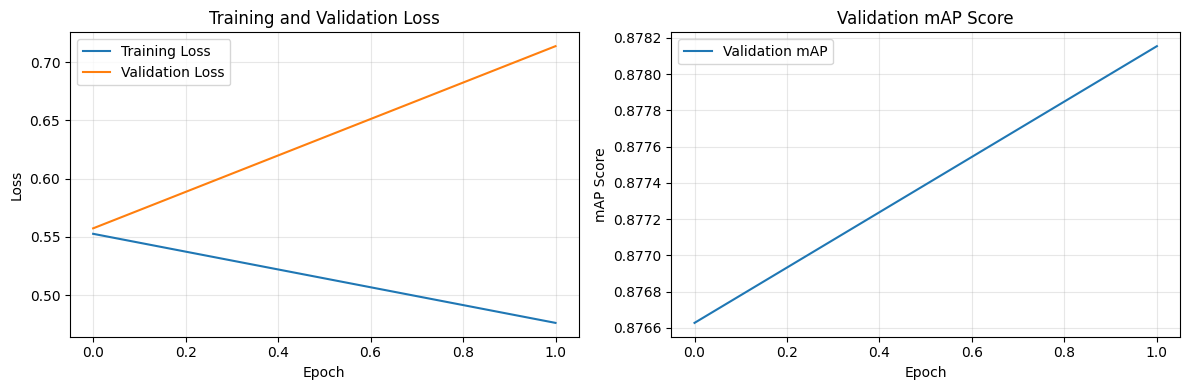

In [13]:
plot_training_history(history)

In [ ]:
# With weighted BCE for imbalanced datasets (auto-calculated weights)
model, history = train_model(model=model, 
                             train_loader=train_loader,
                             val_loader=val_loader, 
                             class_names=classes,
                             loss_function="smooth_bce",
                             num_epochs=2, 
                             learning_rate=0.001,
                             use_kfold=False  # Set to False for standard training
                             )

In [ ]:
# With weighted BCE for imbalanced datasets (auto-calculated weights)
model, history = train_model(model=model, 
                             train_loader=train_loader,
                             val_loader=val_loader, 
                             class_names=classes,
                             loss_function="focal",
                             num_epochs=2, 
                             learning_rate=0.001,
                             use_kfold=False  # Set to False for standard training
                             )